In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
np.random.seed(42)

# Create synthetic dataset with 1000 rows and 10 features
df= pd.DataFrame({
    "age": np.random.normal(30,5,1000),
    "salary": np.random.normal(50000,12000,1000),
    "expenses": np.random.normal(20000,5000,1000),
    "savings": np.random.normal(10000,3000,1000),
    "transactions": np.random.poisson(10,1000),
    "credit_score": np.random.normal(650,50,1000),
    "loan_amount": np.random.normal(200000,50000,1000),
    "purchase_freq": np.random.poisson(5,1000),
    "height": np.random.normal(170,10,1000),
    "weight": np.random.normal(70,15,1000),
    "gender": np.random.choice(["Male","Female"],size=1000),
    "department": np.random.choice(["HR","Finance","IT","Sales"],size=1000),
    "city": np.random.choice(["Delhi","Mumbai","Bangalore","Hyderabad"],size=1000)
})
threshold = 0.2
for col in df.columns:
    # Randomly choose fraction up to threshold
    frac_missing = np.random.uniform(0,threshold)
    df.loc[df.sample(frac=frac_missing).index,col] = np.nan

## data inspection & quantify missingness(EDA)

In [9]:
df.head()

,age,salary,expenses,savings,transactions,credit_score,loan_amount,purchase_freq,height,weight,gender,department,city
0,32.483571,66792.265239,16624.108625,4276.577326,10.0,693.359371,280280.991628,2.0,181.408960,104.615323,Male,HR,Mumbai
1,29.308678,61095.604195,19277.406646,7418.844968,11.0,625.132281,95962.973730,6.0,156.361321,58.844501,Female,Sales,Hyderabad
2,33.238443,50715.564439,16037.900395,8759.183400,10.0,678.822567,260290.921036,8.0,173.997799,65.227861,Male,IT,Bangalore
3,37.615149,42236.758668,18460.192352,15663.062972,4.0,574.572202,153160.238252,5.0,163.192336,69.224531,Male,IT,Bangalore
4,NaN,NaN,10531.926665,11669.659374,14.0,659.248529,131396.040637,4.0,NaN,59.689683,Male,IT,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            843 non-null    float64
 1   salary         823 non-null    float64
 2   expenses       878 non-null    float64
 3   savings        874 non-null    float64
 4   transactions   945 non-null    float64
 5   credit_score   943 non-null    float64
 6   loan_amount    994 non-null    float64
 7   purchase_freq  906 non-null    float64
 8   height         846 non-null    float64
 9   weight         924 non-null    float64
 10  gender         988 non-null    object 
 11  department     883 non-null    object 
 12  city           878 non-null    object 
dtypes: float64(10), object(3)
memory usage: 101.7+ KB


In [11]:
df.isnull().sum()

age              157
salary           177
expenses         122
savings          126
transactions      55
credit_score      57
loan_amount        6
purchase_freq     94
height           154
weight            76
gender            12
department       117
city             122
dtype: int64

In [12]:
df.isnull().mean()*100

age              15.7
salary           17.7
expenses         12.2
savings          12.6
transactions      5.5
credit_score      5.7
loan_amount       0.6
purchase_freq     9.4
height           15.4
weight            7.6
gender            1.2
department       11.7
city             12.2
dtype: float64

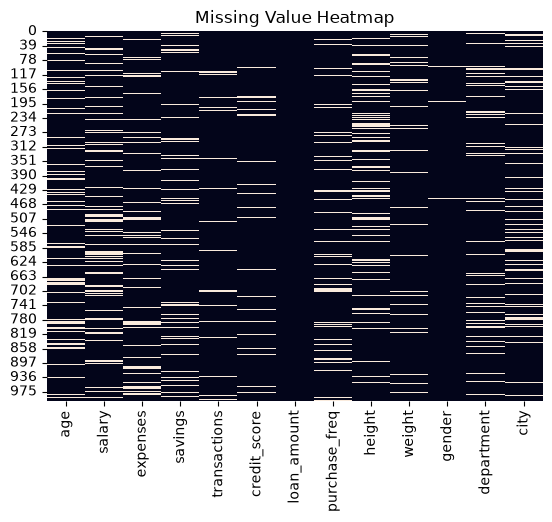

In [36]:
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Value Heatmap")
print("==="*50)

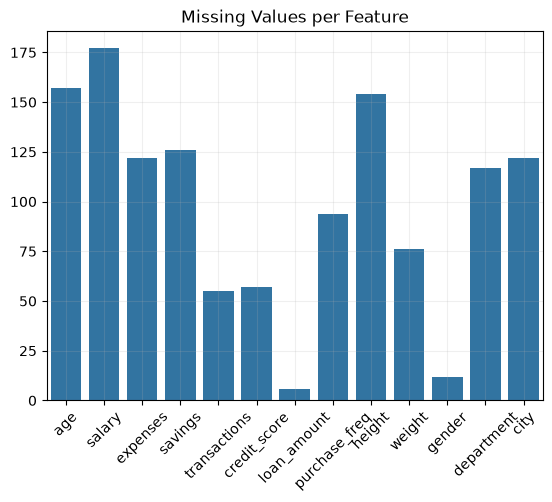

In [40]:
sns.barplot(df.isnull().sum())
plt.title("Missing Values per Feature")
plt.xticks(rotation=45)
plt.grid(alpha=.2)

## strategy 1 - drop row / column

In [14]:
#threshold is 10 
# droping columns which contain null values
drop_col=df.columns[df.isnull().mean()>.01]
drop_col

Index(['age', 'salary', 'expenses', 'savings', 'transactions', 'credit_score',
       'purchase_freq', 'height', 'weight', 'gender', 'department', 'city'],
      dtype='object')

In [15]:
clean_data=df.drop(columns=drop_col)
clean_data.isnull().mean()*100

loan_amount    0.6
dtype: float64

In [16]:
# droping rows 
df[df.isnull().sum(axis=1)<.1].isnull().sum()

age              0
salary           0
expenses         0
savings          0
transactions     0
credit_score     0
loan_amount      0
purchase_freq    0
height           0
weight           0
gender           0
department       0
city             0
dtype: int64

## droping only null values

In [17]:
# columns
df.dropna(axis=1).isnull().sum()

Series([], dtype: float64)

In [18]:
# rows
df.dropna(axis=0).isnull().sum()


age              0
salary           0
expenses         0
savings          0
transactions     0
credit_score     0
loan_amount      0
purchase_freq    0
height           0
weight           0
gender           0
department       0
city             0
dtype: int64

## Strategy 2 – Simple Imputation

Simple imputation replaces missing values using a statistical measure such as the mean, median, or most frequent value.

Advantages:
- Easy to implement
- Fast

Disadvantages:
- Can introduce bias
- Reduces variance

In [19]:
# using pandas
data=df.copy()
data_num=data.select_dtypes(include=[np.number])
data_cat=data.select_dtypes(include="object")

In [20]:
for i in data_num:
    data[i]=data[i].fillna(df[i].mean())
for i in data_cat:
    data[i]=data[i].fillna(df[i].mode()[0])
"""we can fill with constant ------------- >   df[i]=df[i].fillna("missing)"""

'we can fill with constant ------------- >   df[i]=df[i].fillna("missing)'

In [21]:
data.head()

,age,salary,expenses,savings,transactions,credit_score,loan_amount,purchase_freq,height,weight,gender,department,city
0,32.483571,66792.265239,16624.108625,4276.577326,10.0,693.359371,280280.991628,2.0,181.408960,104.615323,Male,HR,Mumbai
1,29.308678,61095.604195,19277.406646,7418.844968,11.0,625.132281,95962.973730,6.0,156.361321,58.844501,Female,Sales,Hyderabad
2,33.238443,50715.564439,16037.900395,8759.183400,10.0,678.822567,260290.921036,8.0,173.997799,65.227861,Male,IT,Bangalore
3,37.615149,42236.758668,18460.192352,15663.062972,4.0,574.572202,153160.238252,5.0,163.192336,69.224531,Male,IT,Bangalore
4,30.094273,50838.673693,10531.926665,11669.659374,14.0,659.248529,131396.040637,4.0,170.361121,59.689683,Male,IT,Bangalore


In [22]:
data.isnull().sum()

age              0
salary           0
expenses         0
savings          0
transactions     0
credit_score     0
loan_amount      0
purchase_freq    0
height           0
weight           0
gender           0
department       0
city             0
dtype: int64

In [23]:
# using sklearn
from sklearn.impute import SimpleImputer
num_imp=SimpleImputer(strategy="median")
cat_imp_frq=SimpleImputer(strategy="most_frequent")
con_imp=SimpleImputer(strategy="most_frequent",fill_value="missing")

In [24]:
data=df.copy()
data_num=data.select_dtypes(include=[np.number])
data_cat=data.select_dtypes(include="object")

In [25]:
df.isnull().sum()

age              157
salary           177
expenses         122
savings          126
transactions      55
credit_score      57
loan_amount        6
purchase_freq     94
height           154
weight            76
gender            12
department       117
city             122
dtype: int64

In [26]:
for i in data_num:
    data[i]=num_imp.fit_transform(data[[i]])[:,0]
for i in data_cat:
    data[i]=cat_imp_frq.fit_transform(data[[i]])[:,0]
""" we can implement with constant also  """

' we can implement with constant also  '

In [27]:
data.isnull().sum()

age              0
salary           0
expenses         0
savings          0
transactions     0
credit_score     0
loan_amount      0
purchase_freq    0
height           0
weight           0
gender           0
department       0
city             0
dtype: int64

## strategy - 3 multivarient

In [28]:
# using iterative imputer
from sklearn.experimental import enable_iterative_imputer #is because IterativeImputer is still marked as “experimental”
from sklearn.impute import IterativeImputer

In [29]:
imp=IterativeImputer()

In [30]:
df_imp=pd.DataFrame(imp.fit_transform(df.select_dtypes(include=np.number)),columns=df.select_dtypes(include=np.number).columns)

In [31]:
df_imp.isnull().sum()

age              0
salary           0
expenses         0
savings          0
transactions     0
credit_score     0
loan_amount      0
purchase_freq    0
height           0
weight           0
dtype: int64

## using knn imputer

In [32]:
from sklearn.impute import KNNImputer

In [33]:
knn_imp=KNNImputer()
df_knn_imp=pd.DataFrame(knn_imp.fit_transform(df.select_dtypes(include=np.number)),columns=df.select_dtypes(include=np.number).columns)

In [34]:
df_knn_imp.isnull().sum()

age              0
salary           0
expenses         0
savings          0
transactions     0
credit_score     0
loan_amount      0
purchase_freq    0
height           0
weight           0
dtype: int64

In [35]:
print("--"*50)

----------------------------------------------------------------------------------------------------


| Method       | Best For                | Limitation                |
| ------------ | ----------------------- | ------------------------- |
| Drop Rows    | Very few missing values | Data loss                 |
| Drop Columns | Useless columns         | Feature loss              |
| Mean         | Normal data             | Sensitive to outliers     |
| Median       | Skewed data             | Ignores relationships     |
| Mode         | Categorical data        | Can overuse common values |
| Iterative    | Correlated features     | Slower                    |
| KNN          | Similar observations    | Computationally expensive |


## Conclusion
This project compared several techniques for handling missing values. Simple imputation is fast and suitable for many cases, while Iterative and KNN Imputation can preserve relationships between features at the cost of additional computation.